**Loan Default Prediction**

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score
sns.set_style('whitegrid')

In [2]:
import pandas as pd
# load the data
df = pd.read_csv('/content/Loan_default.csv')

In [3]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36.0,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0.0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60.0,0.68,Master's,Full-time,Married,No,No,Other,Yes,0.0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24.0,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1.0
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24.0,0.23,High School,Full-time,Married,No,No,Business,No,0.0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48.0,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0.0


In [4]:
df.shape

(118588, 18)

In [5]:
df.isnull().sum()

,0
LoanID,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
MonthsEmployed,0
NumCreditLines,0
InterestRate,0
LoanTerm,1
DTIRatio,1


In [6]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,118588.000000,118588.000000,118588.000000,118588.000000,118588.000000,118588.000000,118588.000000,118587.000000,118587.000000,118587.000000
mean,43.516823,82529.857625,127589.693578,574.108350,59.533553,2.497234,13.499115,36.041994,0.500667,0.115114
std,14.974214,39005.130449,70852.325096,158.804077,34.609228,1.117266,6.645131,16.963748,0.230546,0.319161
min,18.000000,15000.000000,5005.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48716.250000,66156.750000,436.000000,30.000000,1.000000,7.770000,24.000000,0.300000,0.000000
50%,43.500000,82578.500000,127455.000000,574.000000,60.000000,2.000000,13.470000,36.000000,0.500000,0.000000
75%,56.000000,116278.250000,188973.250000,711.000000,89.000000,3.000000,19.270000,48.000000,0.700000,0.000000
max,69.000000,149997.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118588 entries, 0 to 118587
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          118588 non-null  object 
 1   Age             118588 non-null  int64  
 2   Income          118588 non-null  int64  
 3   LoanAmount      118588 non-null  int64  
 4   CreditScore     118588 non-null  int64  
 5   MonthsEmployed  118588 non-null  int64  
 6   NumCreditLines  118588 non-null  int64  
 7   InterestRate    118588 non-null  float64
 8   LoanTerm        118587 non-null  float64
 9   DTIRatio        118587 non-null  float64
 10  Education       118587 non-null  object 
 11  EmploymentType  118587 non-null  object 
 12  MaritalStatus   118587 non-null  object 
 13  HasMortgage     118587 non-null  object 
 14  HasDependents   118587 non-null  object 
 15  LoanPurpose     118587 non-null  object 
 16  HasCoSigner     118587 non-null  object 
 17  Default   

Object `default` not found.
Default rate: 11.5%


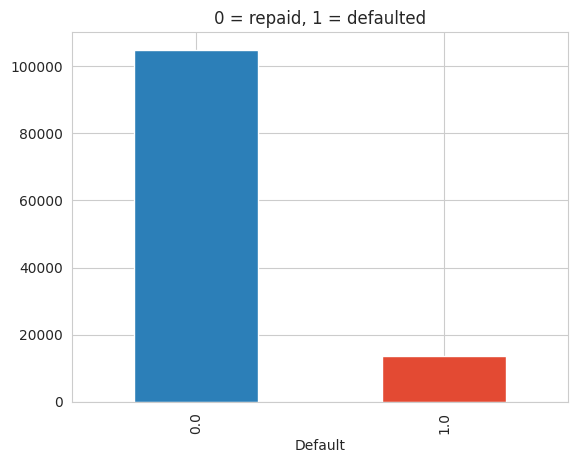

In [8]:
Target balance - what % actually default?
rate = df['Default'].mean()
print(f'Default rate: {rate:.1%}')
df['Default'].value_counts().plot(kind='bar', color=['#2c7fb8','#e34a33'])
plt.title('0 = repaid, 1 = defaulted');plt.show()
# Note: only -12% default. The data is imbalanced - keep an eye on F1, not just as

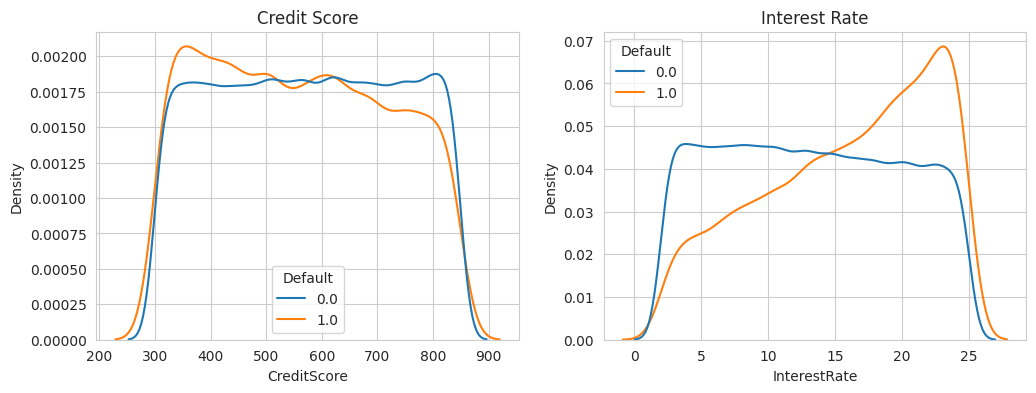

In [9]:
fig, ax = plt.subplots(1,2,figsize=(12,4))
sns.kdeplot(data=df, x='CreditScore', hue= 'Default', common_norm=False, ax=ax[0])
ax[0].set_title('Credit Score')
sns.kdeplot(data=df,  x= 'InterestRate', hue='Default', common_norm=False, ax=ax[1])
ax[1].set_title('Interest Rate')
plt.show()

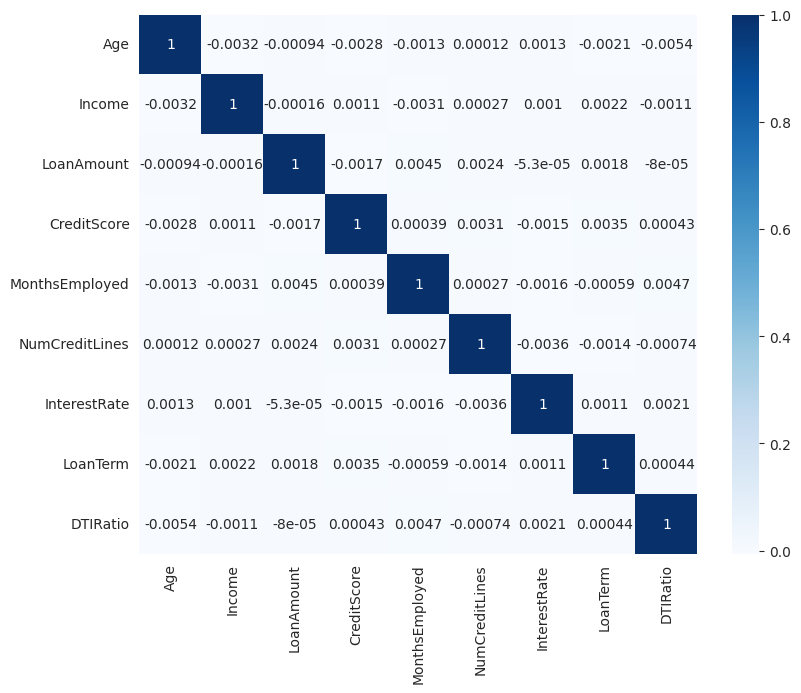

In [10]:
# Correction
num = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
'NumCreditLines','InterestRate', 'LoanTerm', 'DTIRatio']
plt.figure(figsize=(9,7))
sns.heatmap(df[num].corr(), annot=True, cmap='Blues')
plt.show()

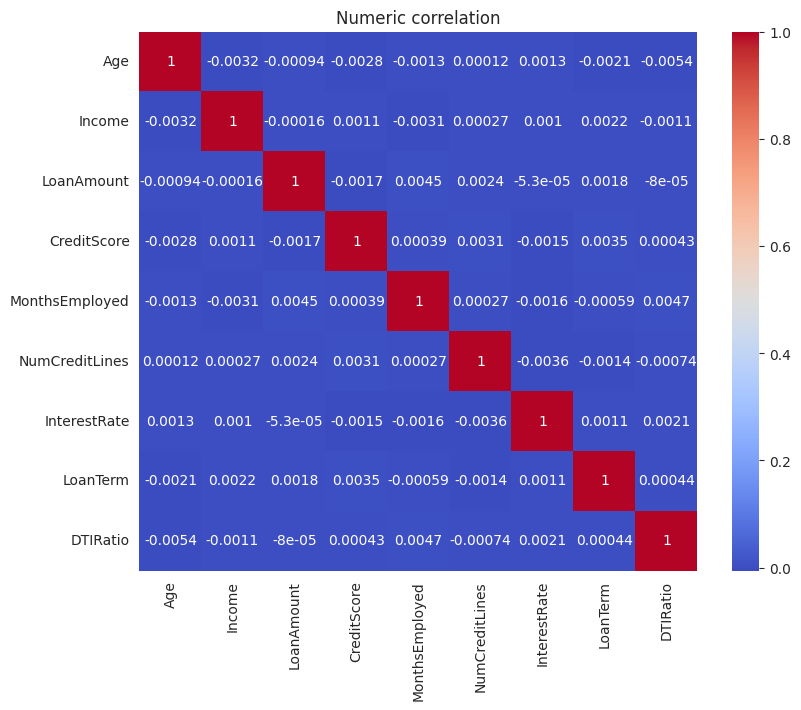

In [11]:
# Correction
num = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
'NumCreditLines','InterestRate', 'LoanTerm', 'DTIRatio']
plt.figure(figsize=(9,7))
sns.heatmap(df[num].corr(), annot=True, cmap='coolwarm')
plt.title('Numeric correlation'); plt.show()

In [13]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36.0,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0.0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60.0,0.68,Master's,Full-time,Married,No,No,Other,Yes,0.0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24.0,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1.0
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24.0,0.23,High School,Full-time,Married,No,No,Business,No,0.0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48.0,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0.0


**One-hot-encoding**

In [14]:
import pandas as pd

df = pd.read_csv('/content/Loan_default.csv')

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nObject columns:")
print(df.select_dtypes(include='object').columns.tolist())

Shape: (255347, 18)

Columns:
['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']

Object columns:
['LoanID', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']


In [15]:
df_enc = pd.get_dummies(df.drop(columns=['LoanID']),drop_first=True)
X = df_enc.drop(columns=['Default'])
y = df_enc['Default']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print('Train:', X_train.shape, 'Test:', X_test.shape)


Train: (204277, 24) Test: (51070, 24)


In [16]:
# Encode only the categorical columns
cat_cols = df.select_dtypes(include='object').columns

print(df[cat_cols].nunique())

LoanID            255347
Education              4
EmploymentType         4
MaritalStatus          3
HasMortgage            2
HasDependents          2
LoanPurpose            5
HasCoSigner            2
dtype: int64


**MODEL BUILDING**

In [17]:
# Train a logistic regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'Liblinear'is good for small data
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Evaluate the model
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)

print(f"Logistic Regression - Accuracy: {accuracy_log_reg:.4f}")
print(f"LogisticRegression F1-score: {f1_log_reg:.4f}")

Logistic Regression - Accuracy: 0.8849
LogisticRegression F1-score: 0.0249


**Logistic Regression Feature Importance**

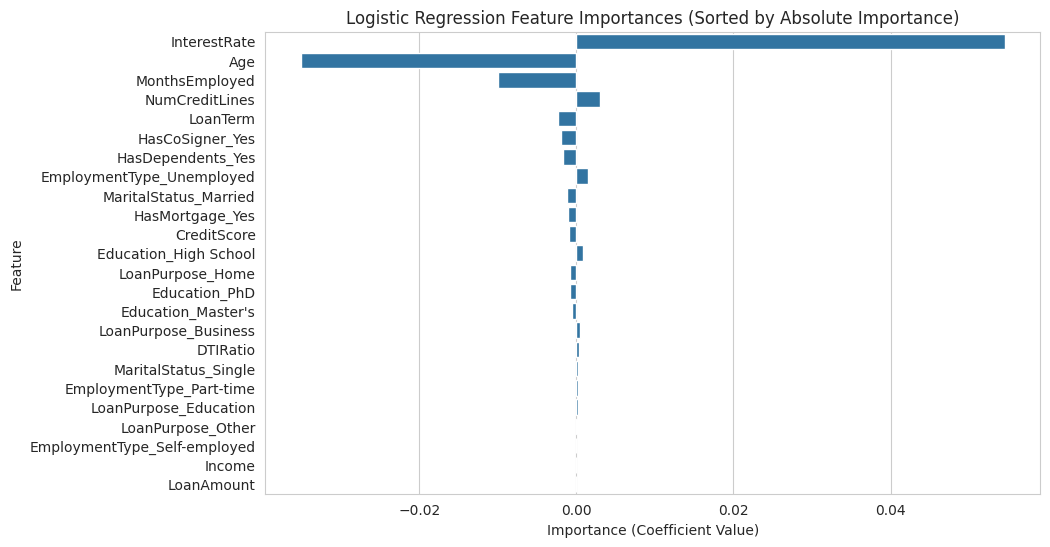

In [18]:
feature_importance_log = pd.DataFrame({'Feature': X_train.columns, 'Importance': log_reg_model.coef_[0]})

feature_importance_log['absolute importance'] = feature_importance_log['Importance'].abs()
feature_importance_log = feature_importance_log.sort_values(by='absolute importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_log)
plt.title('Logistic Regression Feature Importances (Sorted by Absolute Importance)')
plt.xlabel('Importance (Coefficient Value)')
plt.ylabel('Feature')
plt.show()

**Random Forest**

In [19]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train,y_train)
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

In [ ]:
#Evaluate the model
print(f"Random Forest - Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest F1-score: {f1_rf:.4f}")

Random Forest - Accuracy: 0.8849
Random Forest F1-score: 0.0104


In [20]:
feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
    }).sort_values(by='Importance',
                   ascending=False)

feature_importance_rf

,Feature,Importance
0,Age,0.233990
1,Income,0.188544
6,InterestRate,0.164733
2,LoanAmount,0.117771
4,MonthsEmployed,0.098850
3,CreditScore,0.048633
8,DTIRatio,0.034293
5,NumCreditLines,0.013695
23,HasCoSigner_Yes,0.012642
7,LoanTerm,0.012154


**XGBOOST**

In [21]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=10, random_state=42,
    eval_metric='logloss'
    )

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print(f"XGBoost - Accuracy: {accuracy_xgb:.4f}")
print(f"XGBoost F1-score: {f1_xgb:.4f}")

XGBoost - Accuracy: 0.8870
XGBoost F1-score: 0.1344


**XGBOOST FEATURE IMPORTANCE**

In [22]:
feature_importance_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
    }).sort_values(
        by='Importance',
                   ascending=False)

feature_importance_xgb

,Feature,Importance
0,Age,0.086675
6,InterestRate,0.057674
1,Income,0.055446
2,LoanAmount,0.048337
23,HasCoSigner_Yes,0.047958
14,EmploymentType_Unemployed,0.047513
4,MonthsEmployed,0.047217
18,HasDependents_Yes,0.045739
15,MaritalStatus_Married,0.042906
21,LoanPurpose_Home,0.040094


**COMPARE ALL THREE MODELS**

In [23]:
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression',
              'Random Forest',
              'XGBoost'
              ],
    'Accuracy': [
        accuracy_log_reg,
        accuracy_rf,
        accuracy_xgb
        ],
    'F1-Score': [
        f1_log_reg,
        f1_rf,
        f1_xgb]
})

display(model_comparison.sort_values(by='F1-Score', ascending=False))

,Model,Accuracy,F1-Score
2,XGBoost,0.886959,0.134353
0,Logistic Regression,0.884903,0.024884
1,Random Forest,0.884923,0.010439


/tmp/ipykernel_22908/739879052.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='F1-Score', data=model_comparison.sort_values(by='F1-Score', ascending=False), palette='viridis')


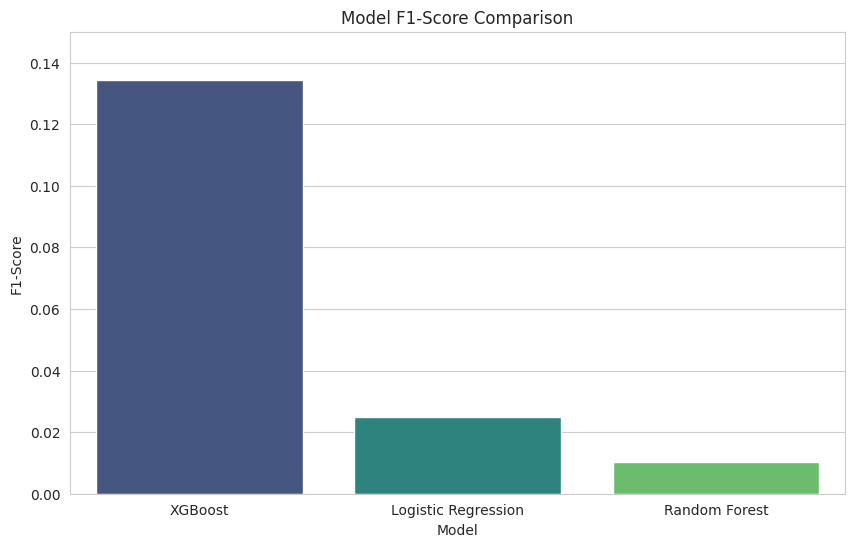

In [24]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='F1-Score', data=model_comparison.sort_values(by='F1-Score', ascending=False), palette='viridis')
plt.title('Model F1-Score Comparison')
plt.ylabel('F1-Score')
plt.xlabel('Model')
plt.ylim(0, 0.15) # Set a reasonable y-limit based on the F1-scores
plt.show()

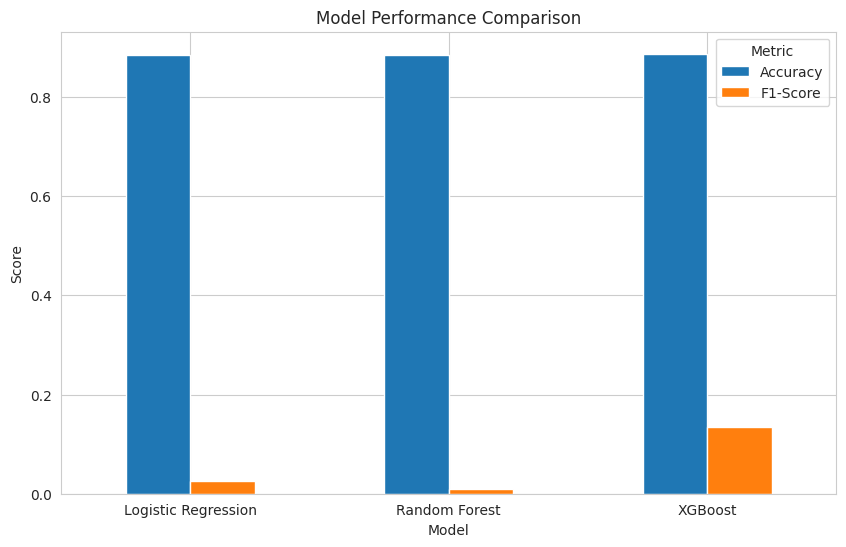

In [25]:
model_comparison.set_index('Model')[['Accuracy','F1-Score']].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.show()

### Model Comparison and Best Model Selection

Looking at the comparison table, we can draw some conclusions about which model is performing better for our loan default prediction task:

*   **Accuracy:** All three models show relatively high accuracy (around 88-89%). However, as we've discussed, accuracy can be misleading in imbalanced datasets because a model can achieve high accuracy by simply predicting the majority class most of the time (i.e., predicting 'no default' for almost everyone).

*   **F1-Score:** This is where the true performance for our imbalanced dataset becomes apparent. The F1-score balances precision and recall, providing a better measure of a model's ability to correctly identify positive instances (defaults) while minimizing false positives and false negatives.
    *   **XGBoost** has a significantly higher F1-score (0.1344) compared to Logistic Regression (0.0249) and Random Forest (0.0104).

**Conclusion:**

Based on the **F1-score**, which is the most appropriate metric for our imbalanced loan default dataset, the **XGBoost model is performing the best** among the three. While all models have similar overall accuracy, XGBoost is doing a much better job at identifying the actual defaulting cases (the minority class) without being overly inaccurate on the non-defaulting cases.

This suggests that XGBoost is better at handling the complexities and imbalances in the data to make more reliable predictions for loan defaults.

### Explanation of Model Comparison Visualizations

#### First Visualization (Cell `4aa2c194`): F1-Score Comparison

This code generates a bar chart that specifically highlights the F1-scores of each model.

```python
plt.figure(figsize=(10, 6))
```
This line creates a new figure (the canvas for your plot) and sets its size to 10 inches wide by 6 inches tall.

```python
sns.barplot(x='Model', y='F1-Score', data=model_comparison.sort_values(by='F1-Score', ascending=False), palette='viridis')
```
This is the core plotting command using Seaborn's `barplot` function:
*   `x='Model'` specifies that the 'Model' column from your data should be used for the x-axis, representing each model's name.
*   `y='F1-Score'` specifies that the 'F1-Score' column should be used for the y-axis, indicating the metric being plotted.
*   `data=model_comparison.sort_values(by='F1-Score', ascending=False)` provides the DataFrame `model_comparison` as the source of data for the plot. It also sorts this DataFrame by 'F1-Score' in descending order, so the best-performing model (by F1-score) appears first.
*   `palette='viridis'` applies a specific color scheme to the bars.

```python
plt.title('Model F1-Score Comparison')
```
This sets the main title of the plot.

```python
plt.ylabel('F1-Score')
```
This sets the label for the y-axis.

```python
plt.xlabel('Model')
```
This sets the label for the x-axis.

```python
plt.ylim(0, 0.15) # Set a reasonable y-limit based on the F1-scores
```
This explicitly sets the y-axis limits from 0 to 0.15. This is important because F1-scores are relatively low in this dataset, and setting a specific limit helps to visually emphasize the differences between the models' F1-scores.

```python
plt.show()
```
This command displays the generated plot.

#### Second Visualization (Cell `aCrmmipxn1_v`): Model Performance Comparison (Accuracy and F1-Score)

This code generates a grouped bar chart that compares both Accuracy and F1-Score for each model.

```python
model_comparison.set_index('Model')[['Accuracy','F1-Score']].plot(
    kind='bar',
    figsize=(10,6)
)
```
This line uses Pandas' built-in plotting functionality (which leverages Matplotlib):
*   `model_comparison.set_index('Model')` sets the 'Model' column as the DataFrame's index. This is a common step when you want the index values to be the labels on your plot (in this case, the model names).
*   `[['Accuracy','F1-Score']]` selects only the 'Accuracy' and 'F1-Score' columns for plotting.
*   `.plot(kind='bar', figsize=(10,6))` tells Pandas to create a bar chart (`kind='bar'`) and sets the figure size.

```python
plt.title("Model Performance Comparison")
```
This sets the main title of the plot.

```python
plt.ylabel("Score")
```
This sets the label for the y-axis.

```python
plt.xticks(rotation=0)
```
This ensures that the x-axis labels (model names) are displayed horizontally, without rotation.

```python
plt.legend(title="Metric")
```
This adds a legend to the plot, which is crucial here to differentiate between the 'Accuracy' bars and the 'F1-Score' bars. It also gives the legend a title 'Metric'.

```python
plt.show()
```
This command displays the generated plot.

### Similarities and Differences Between the Visualizations

**Similarities:**
*   **Purpose:** Both plots aim to visually compare the performance of the three machine learning models (Logistic Regression, Random Forest, and XGBoost).
*   **Data Source:** Both plots draw their data from the `model_comparison` DataFrame.
*   **Type of Chart:** Both are bar charts, which are effective for comparing discrete categories.
*   **Libraries Used:** Both rely on Matplotlib for rendering the plots, with the first one using Seaborn as an abstraction and the second using Pandas' plotting interface.

**Differences:**
*   **Metrics Displayed:**
    *   The **first plot** is focused solely on the **F1-Score**, showing one bar per model.
    *   The **second plot** displays **both Accuracy and F1-Score** for each model, using grouped bars.
*   **Visual Emphasis:**
    *   The **first plot** explicitly sorts models by F1-Score and uses a `ylim` to magnify the (small) differences in F1-scores, making it easier to see which model truly performs best on the F1-score metric.
    *   The **second plot** shows accuracy and F1-score on the same scale (0 to 1). This makes the high accuracy scores visually dominate, while the much lower F1-scores appear very small in comparison. This can sometimes make it harder to discern the nuances of the F1-score performance.
*   **Sorting:**
    *   The **first plot** explicitly sorts the models by their F1-Score, providing an immediate visual ranking.
    *   The **second plot** displays models in their original order from the DataFrame, without explicit sorting.
*   **Legend:**
    *   The **first plot** does not require a legend as it only visualizes one metric.
    *   The **second plot** uses a legend to distinguish between the 'Accuracy' and 'F1-Score' bars for each model.

**SELECT THE BEST MODEL AUTOMATICALLY**

In [26]:
best_model_name = model_comparison.sort_values(by='F1-Score', ascending=False).iloc[0]['Model']

print(f"The best model is: {best_model_name}")

The best model is: XGBoost


**SAVE MODEL**

In [27]:
import joblib

if best_model_name == 'Logistic Regression':
    best_model = log_reg_model
elif best_model_name == 'Random Forest':
    best_model = rf_model
else:
    best_model = xgb_model

joblib.dump(best_model, 'loan_default_model.pkl')

print("Best model saved successfully!")

Best model saved successfully!


**STREAMLIT APPLICATION**

**app.py**

In [29]:
app_py_content =
import streamlit as st
import pandas as pd
import joblib

# PAGE CONFIGURATION

st.set_page_config(
    page_title='Loan Default Prediction',
    page_icon='💰',
    layout='wide',
    initial_sidebar_state='expanded'
)
# LOAD MODEL
model = joblib.load('loan_default_model.pkl')

# CUSTOM CSS

st.markdown(***
 <style>

 main {

 background-color: #FBFAC;
 }
 .title {
   text-align: center;
   color: #2c7fb8;
   font-size: 40px;
   font-weight: 700;
 }
 .subtitle {
   text-align: center;
   color: #647488;
   font-size: 18px;
   font-weight: 400;
 }
 .metric-card {
  background-color:white;
  padding:15px;
  border-radius:12px;
  box-shadow: 0 2px 10px rgba(0, 0, 0, 0.8):
 }

  .stButton > button {
   width:100%;
   height:55px;
   border-radius:12px;
   font-size:18px;
   font-weight:bold;
  }
  </style>
   ..., unsafe_allow_html=True)

# SIDEBAR
  with st.sidebar:

    st.image(
        "https://cdn.icons.png.flaticon.com/512/3135/3135715.png",
        width=150
    )

    st.title("[i] Project Overview")

    st.markdown(***
    ### Models used

    Logistic Regression)
    Random Forest
    XGBoost

    ### Objective

   Predict wether a borroweris likely to default on a loan,

  ### Features
  Real-time prediction
  Risk probability
  ML-powered decision support
  ***)

  st.divider()

  st.info(
    "Buit with Streamlit, Scikit-Learn and XGBOOST."
    )

    # HEADERS

    st.markdown(
        "<p class='title'> - Loan Default Prediction System(/p>",
        unsafe_allow_html=True
    )

    st.markdown(
        "<p class='subtitle'>Machine Learning Powered Credit Risk Assessment Dashboard
        unsafe_allow_html=True"
    )

    st.divider()

    # INPUT SECTION

    col1, col2, col3 = st.columns(3)

    with col1:

      Age = st.number_input(
          "Age",
          min_value=18,
          max_value=100,
          value=30,

      )

      Income = st.number_input(
          "Income",
          min_value=1000,
          value=50000,

      )
      LoanAmount = st.number_input(
          "Loan Amount",
          min_value=1000,
          value=10000,

      )

    with col2:
      creditscore = st.number_input(
          "Credit Score",
          min_value=300,
          max_value=850,
          value=650,
      )

      InterestRate = st.number_input(
          "Interest Rate(%)",
          min_value=1.0,
          max_value=40.0,
          value=12.5,

      )

      LoanTerm = st.number_input(
          "Loan Term(Months)",
          min_value=6,
          max_value=360,
          value=36,

      )
    with col3:

      MonthsEmployed = st.number_input(
          "Months Employed",
          min_value=0,
          value=24,

      )

      NumCreditLines = st.number_input(
          "Number of Credit Lines",
          min_value=0,
          value=5,

      )

      DTIRatio = st.number_input(
          "Debt-to-Income Ratio",
          min_value=0.0,
          max_value=1.0,
          value=0.30,

      )

      #PREDICTION

      if st.button("Predict Loan Risk"):

        # Create a dictionary for input features
        input_dict = {
            'Age':[Age],
            'Income':[Income],
            'LoanAmount':[LoanAmount],
            'CreditScore':[creditscore],
            'MonthsEmployed':[MonthsEmployed],
            'NumCreditLines':[NumCreditLines],
            'DTIRatio':[DTIRatio],
            'InterestRate':[InterestRate],
            'LoanTerm':[LoanTerm],
        }

        # Create a DataFrame From the input dictionary
        input_df = pd.DataFrame(input_dict)

        # Get the column names from the training data X
        # This list is obtained from the kernel state's  'X' variable.
        expected_columns = [
            'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
            'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio',
            'Education_High School', "Education_Master's",'Education_PhD',
            'Employment_Type_Pertime', 'Employment_Type_Self_emoloyed',
            'Employment_Type_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single',
            'HasMortgage_Yes', 'HasDependent_Yes', 'LoanPurpose_Business', 'LoanPurpose_Education',
            'LoanPurpose_Home', 'LoanPurpose_Other', 'HasCosigner_Yes']

            # Create an empty dataframe with all expected columns
            final_input_df = pd.DataFrame(columns=expected_columns)

            # Populate the known numeric
            for col input_data_df.np.column:
              if col not in final_input_df.columns:
                final_input_df[col] = 0

            # Ensure the order of column matches the training data 'X'
            final_input_df = final_input_df[expected_columns]

            prediction = model.predict(final_input_df)[0]

            probability = model.predict_proba(final_input_df)[0][1]

            st.divider()

            st.subheader("Prediction Result")

            colA, colB = st.columns(2)

            with colA:
              if prediction == 1:

                st.error(
                    f***

                    # HIGH DEFAULT RISK

                    Probability of Default:
                    {probability:.2%}
                    ***
                )
                else
                st.success(
                    f***

                    # Low Default  Risk

                    Confidence:
                    {(1-probability):.2%}
                    ***
                )

                with col8:
                  st.metric{
                      "Default Probability",
                      f"{probability:.2%}"
                  }

                  st.progress(float(probability))
                st.metric(
                    "Risk Level",
                    "High Risk" if prediction == 1 else "Low Risk"
                )

            with colB:
              if prediction == 1:
                st.success(
                    f***

                    # LOW DEFAULT RISK

                    Probability of Default:
                    {probability:.2%}
                    ***
                )

            # Add the input data to the final dataframe
            final_input_df = pd.concat([final_input_df, input_df], ignore_index=True)

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 73)

In [ ]:
app_py_content =
import streamlit as st
import pandas as pd
import joblib

# PAGE CONFIGURATION

st.set_page_config(
    page_title='Loan Default Prediction',
    page_icon='💰',
    layout='wide',
    initial_sidebar_state='expanded'
)
# LOAD MODEL
model = joblib.load('loan_default_model.pkl')

# CUSTOM CSS

st.markdown(***
 <style>

 main {

 background-color: #FBFAC;
 }
 .title {
   text-align: center;
   color: #2c7fb8;
   font-size: 40px;
   font-weight: 700;
 }
 .subtitle {
   text-align: center;
   color: #647488;
   font-size: 18px;
   font-weight: 400;
 }
 .metric-card {
  background-color:white;
  padding:15px;
  border-radius:12px;
  box-shadow: 0 2px 10px rgba(0, 0, 0, 0.8):
 }

  .stButton > button {
   width:100%;
   height:55px;
   border-radius:12px;
   font-size:18px;
   font-weight:bold;
  }
  </style>
   ..., unsafe_allow_html=True)

# SIDEBAR
  with st.sidebar:

    st.image(
        "https://cdn.icons.png.flaticon.com/512/3135/3135715.png",
        width=150
    )

    st.title("[i] Project Overview")

    st.markdown(***
    ### Models used

    Logistic Regression)
    Random Forest
    XGBoost

    ### Objective

   Predict wether a borroweris likely to default on a loan,

  ### Features
  Real-time prediction
  Risk probability
  ML-powered decision support
  ***)

  st.divider()

  st.info(
    "Buit with Streamlit, Scikit-Learn and XGBOOST."
    )

    # HEADERS

    st.markdown(
        "<p class='title'> - Loan Default Prediction System(/p>",
        unsafe_allow_html=True
    )

    st.markdown(
        "<p class='subtitle'>Machine Learning Powered Credit Risk Assessment Dashboard
        unsafe_allow_html=True"
    )

    st.divider()

    # INPUT SECTION

    col1, col2, col3 = st.columns(3)

    with col1:

      Age = st.number_input(
          "Age",
          min_value=18,
          max_value=100,
          value=30,

      )

      Income = st.number_input(
          "Income",
          min_value=1000,
          value=50000,

      )
      LoanAmount = st.number_input(
          "Loan Amount",
          min_value=1000,
          value=10000,

      )

    with col2:
      creditscore = st.number_input(
          "Credit Score",
          min_value=300,
          max_value=850,
          value=650,
      )

      InterestRate = st.number_input(
          "Interest Rate(%)",
          min_value=1.0,
          max_value=40.0,
          value=12.5,

      )

      LoanTerm = st.number_input(
          "Loan Term(Months)",
          min_value=6,
          max_value=360,
          value=36,

      )
    with col3:

      MonthsEmployed = st.number_input(
          "Months Employed",
          min_value=0,
          value=24,

      )

      NumCreditLines = st.number_input(
          "Number of Credit Lines",
          min_value=0,
          value=5,

      )

      DTIRatio = st.number_input(
          "Debt-to-Income Ratio",
          min_value=0.0,
          max_value=1.0,
          value=0.30,

      )

      #PREDICTION

      if st.button("Predict Loan Risk"):

        # Create a dictionary for input features
        input_dict = {
            'Age':[Age],
            'Income':[Income],
            'LoanAmount':[LoanAmount],
            'CreditScore':[creditscore],
            'MonthsEmployed':[MonthsEmployed],
            'NumCreditLines':[NumCreditLines],
            'DTIRatio':[DTIRatio],
            'InterestRate':[InterestRate],
            'LoanTerm':[LoanTerm],
        }

        # Create a DataFrame From the input dictionary
        input_df = pd.DataFrame(input_dict)

        # Get the column names from the training data X
        # This list is obtained from the kernel state's  'X' variable.
        expected_columns = [
            'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
            'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio',
            'Education_High School', "Education_Master's",'Education_PhD',
            'Employment_Type_Pertime', 'Employment_Type_Self_emoloyed',
            'Employment_Type_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single',
            'HasMortgage_Yes', 'HasDependent_Yes', 'LoanPurpose_Business', 'LoanPurpose_Education',
            'LoanPurpose_Home', 'LoanPurpose_Other', 'HasCosigner_Yes']

            # Create an empty dataframe with all expected columns
            final_input_df = pd.DataFrame(columns=expected_columns)

            # Populate the known numeric
            for col input_data_df.np.column:
              if col not in final_input_df.columns:
                final_input_df[col] = 0

            # Ensure the order of column matches the training data 'X'
            final_input_df = final_input_df[expected_columns]

            prediction = model.predict(final_input_df)[0]

            probability = model.predict_proba(final_input_df)[0][1]

            st.divider()

            st.subheader("Prediction Result")

            colA, colB = st.columns(2)

            with colA:
              if prediction == 1:

                st.error(
                    f***

                    # HIGH DEFAULT RISK

                    Probability of Default:
                    {probability:.2%}
                    ***
                )
                else
                st.success(
                    f***

                    # Low Default  Risk

                    Confidence:
                    {(1-probability):.2%}
                    ***
                )

                with col8:
                  st.metric{
                      "Default Probability",
                      f"{probability:.2%}"
                  }

                  st.progress(float(probability))
                st.metric(
                    "Risk Level",
                    "High Risk" if prediction == 1 else "Low Risk"
                )

            with colB:
              if prediction == 1:
                st.success(
                    f***

                    # LOW DEFAULT RISK

                    Probability of Default:
                    {probability:.2%}
                    ***
                )

            # Add the input data to the final dataframe
            final_input_df = pd.concat([final_input_df, input_df], ignore_index=True)

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 73)

In [33]:
app_py_content = """
import streamlit as st
import pandas as pd
import joblib

# PAGE CONFIGURATION

st.set_page_config(
    page_title='Loan Default Prediction',
    page_icon='💰',
    layout='wide',
    initial_sidebar_state='expanded'
)
# LOAD MODEL
model = joblib.load('loan_default_model.pkl')

# CUSTOM CSS

st.markdown('''
 <style>

 main {

 background-color: #FBFAC;
 }
 .title {
   text-align: center;
   color: #2c7fb8;
   font-size: 40px;
   font-weight: 700;
 }
 .subtitle {
   text-align: center;
   color: #647488;
   font-size: 18px;
   font-weight: 400;
 }
 .metric-card {
  background-color:white;
  padding:15px;
  border-radius:12px;
  box-shadow: 0 2px 10px rgba(0, 0, 0, 0.8);
 }

  .stButton > button {
   width:100%;
   height:55px;
   border-radius:12px;
   font-size:18px;
   font-weight:bold;
  }
  </style>
   ''', unsafe_allow_html=True)

# SIDEBAR
with st.sidebar:

    st.image(
        "https://cdn.icons.png.flaticon.com/512/3135/3135715.png",
        width=150
    )

    st.title("[i] Project Overview")

    st.markdown('''
    ### Models used

    Logistic Regression
    Random Forest
    XGBoost

    ### Objective

   Predict whether a borrower is likely to default on a loan.

  ### Features
  Real-time prediction
  Risk probability
  ML-powered decision support
  ''')

    st.divider()

    st.info(
    "Built with Streamlit, Scikit-Learn and XGBOOST."
    )

# HEADERS

st.markdown(
    "<p class='title'>Loan Default Prediction System</p>",
    unsafe_allow_html=True
)

st.markdown(
    "<p class='subtitle'>Machine Learning Powered Credit Risk Assessment Dashboard</p>",
    unsafe_allow_html=True
)

st.divider()

# INPUT SECTION

col1, col2, col3 = st.columns(3)

with col1:

    Age = st.number_input(
        "Age",
        min_value=18,
        max_value=100,
        value=30,

    )

    Income = st.number_input(
        "Income",
        min_value=1000,
        value=50000,

    )
    LoanAmount = st.number_input(
        "Loan Amount",
        min_value=1000,
        value=10000,

    )

with col2:
    creditscore = st.number_input(
        "Credit Score",
        min_value=300,
        max_value=850,
        value=650,
    )

    InterestRate = st.number_input(
        "Interest Rate(%)",
        min_value=1.0,
        max_value=40.0,
        value=12.5,

    )

    LoanTerm = st.number_input(
        "Loan Term(Months)",
        min_value=6,
        max_value=360,
        value=36,

    )
with col3:

    MonthsEmployed = st.number_input(
        "Months Employed",
        min_value=0,
        value=24,

    )

    NumCreditLines = st.number_input(
        "Number of Credit Lines",
        min_value=0,
        value=5,

    )

    DTIRatio = st.number_input(
        "Debt-to-Income Ratio",
        min_value=0.0,
        max_value=1.0,
        value=0.30,

    )

    #PREDICTION

    if st.button("Predict Loan Risk"):

        # Create a dictionary for input features
        input_dict = {
            'Age':[Age],
            'Income':[Income],
            'LoanAmount':[LoanAmount],
            'CreditScore':[creditscore],
            'MonthsEmployed':[MonthsEmployed],
            'NumCreditLines':[NumCreditLines],
            'DTIRatio':[DTIRatio],
            'InterestRate':[InterestRate],
            'LoanTerm':[LoanTerm],
        }

        # Get the column names from the training data X
        # This list is obtained from the kernel state's  'X' variable.
        expected_columns = [
            'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
            'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio',
            'Education_High School', "Education_Master's",'Education_PhD',
            'Employment_Type_Pertime', 'Employment_Type_Self_emoloyed',
            'Employment_Type_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single',
            'HasMortgage_Yes', 'HasDependent_Yes', 'LoanPurpose_Business', 'LoanPurpose_Education',
            'LoanPurpose_Home', 'LoanPurpose_Other', 'HasCosigner_Yes']

        # Create an empty DataFrame with one row of zeros and all expected columns
        final_input_df = pd.DataFrame(0, index=[0], columns=expected_columns)

        # Populate the relevant columns from the input_dict
        for key, value in input_dict.items():
            if key in final_input_df.columns:
                final_input_df[key] = value[0] # value is a list, take the first element

        prediction = model.predict(final_input_df)[0]

        probability = model.predict_proba(final_input_df)[0][1]

        st.divider()

        st.subheader("Prediction Result")

        colA, colB = st.columns(2)

        with colA:
            if prediction == 1:
                st.error(
                    f'''
                    # HIGH DEFAULT RISK
                    Probability of Default:
                    {probability:.2%}
                    '''
                )
            else:
                st.success(
                    f'''
                    # Low Default Risk
                    Confidence:
                    {(1-probability):.2%}
                    '''
                )

        with colB:
            st.metric(
                "Default Probability",
                f"{probability:.2%}"
            )

            st.progress(float(probability))
            st.metric(
                "Risk Level",
                "High Risk" if prediction == 1 else "Low Risk"
            )

# FOOTER
st.divider()
st.caption(
    "Loan Default Prediction Dashboard | Machine Learning Project"
)
"""

with open("app.py", "w") as f:
    f.write(app_py_content)

print("app.py has been created successfully!")

app.py has been created successfully!
